In [8]:
!pip install pandas pyarrow fastparquet


In [5]:
pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [16]:
#Import libraaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [14]:
# =====================================================
# STEP 3 : CHECK DATASET DIMENSIONS
# Purpose:
# Verify that all files are loaded successfully
# =====================================================

print("Loans:", loans.shape)
print("Bureau:", bureau.shape)
print("Payment:", payment.shape)
print("Performance:", performance.shape)
print("EMI:", emi.shape)
print("Collateral:", collateral.shape)
print("Branch:", branch.shape)
print("Card:", card.shape)
print("Enquiry:", enquiry.shape)

Loans: (2000000, 27)
Bureau: (2000000, 30)
Payment: (2000000, 18)
Performance: (2000000, 12)
EMI: (2000000, 23)
Collateral: (2000000, 20)
Branch: (2000000, 19)
Card: (2000000, 17)
Enquiry: (2000000, 24)


In [18]:
# =====================================================
# STEP 5 : CHECK MEMORY USAGE BEFORE DOWNCASTING
# Purpose:
# Measure RAM consumption before optimization
# =====================================================

for name, df in datasets.items():
    
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    
    print(f"{name}: {memory_mb:.2f} MB")

loans: 1564.73 MB
bureau: 1014.09 MB
payment: 373.84 MB
performance: 558.29 MB
emi: 808.17 MB
collateral: 844.51 MB
branch: 664.13 MB
card: 587.13 MB
enquiry: 1109.23 MB


In [13]:
import pandas as pd

loans = pd.read_csv("loans_master.csv")
bureau = pd.read_csv("customer_bureau.csv")
payment = pd.read_csv("payment_history.csv")
performance = pd.read_csv("loan_performance.csv")
emi = pd.read_csv("monthly_emi_track.csv")
collateral = pd.read_csv("collateral_assets.csv")
branch = pd.read_csv("branch_region_economy.csv")
card = pd.read_csv("credit_card_behavior.csv")
enquiry = pd.read_csv("loan_enquiry_bureau.csv")

In [17]:
# =====================================================
# STEP 4 : STORE ALL DATAFRAMES IN A DICTIONARY
# Purpose:
# Makes it easier to perform operations on all datasets
# =====================================================

datasets = {
    "loans": loans,
    "bureau": bureau,
    "payment": payment,
    "performance": performance,
    "emi": emi,
    "collateral": collateral,
    "branch": branch,
    "card": card,
    "enquiry": enquiry
}

In [19]:
# =====================================================
# STEP 6 : CREATE MEMORY OPTIMIZATION FUNCTION
# Purpose:
# Convert int64 → smaller integer types
# Convert float64 → smaller float types
# =====================================================

def reduce_memory(df):

    # Downcast integer columns
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    # Downcast float columns
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    return df

In [20]:
# =====================================================
# STEP 7 : APPLY MEMORY OPTIMIZATION
# =====================================================

for name in datasets:
    
    datasets[name] = reduce_memory(datasets[name])

In [21]:
# =====================================================
# STEP 8 : CHECK MEMORY USAGE AFTER DOWNCASTING
# Purpose:
# Compare memory consumption before and after optimization
# =====================================================

for name, df in datasets.items():
    
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    
    print(f"{name}: {memory_mb:.2f} MB")

loans: 1450.29 MB
bureau: 834.80 MB
payment: 299.45 MB
performance: 510.61 MB
emi: 684.19 MB
collateral: 735.79 MB
branch: 515.36 MB
card: 459.34 MB
enquiry: 918.49 MB


In [22]:
# Display column names of master table

print(loans.columns.tolist())

['loan_id', 'issue_date', 'issue_year', 'issue_month', 'loan_amnt_inr', 'funded_amnt_inr', 'loan_term_months', 'int_rate_pct', 'installment_inr', 'annual_installment_inr', 'grade', 'sub_grade', 'loan_purpose', 'state_code', 'region', 'urban_index', 'application_type', 'pymnt_plan', 'hardship_flag', 'initial_list_status', 'disbursement_method', 'verification_status', 'rbi_repo_rate_pct', 'gdp_growth_pct', 'cpi_inflation_pct', 'rate_spread_pct', 'real_interest_rate_pct']


In [23]:
# Sequential left joins on loan_id
merged_df = loans \
    .merge(bureau, on="loan_id", how="left") \
    .merge(payment, on="loan_id", how="left") \
    .merge(performance, on="loan_id", how="left") \
    .merge(emi, on="loan_id", how="left") \
    .merge(collateral, on="loan_id", how="left") \
    .merge(branch, on="loan_id", how="left") \
    .merge(card, on="loan_id", how="left") \
    .merge(enquiry, on="loan_id", how="left")

In [24]:
# =====================================================
# SAVE MERGED DATASET AS PARQUET
# =====================================================

merged_df.to_parquet(
    "finsight_bank.parquet",
    engine="pyarrow",
    index=False
)

In [25]:
# =====================================================
# CHECK PARQUET FILE SIZE
# =====================================================

import os

parquet_size_mb = os.path.getsize(
    "finsight_bank.parquet"
) / (1024 * 1024)

print(f"Parquet File Size: {parquet_size_mb:.2f} MB")

Parquet File Size: 423.90 MB


In [26]:
print(loans.columns.tolist())

['loan_id', 'issue_date', 'issue_year', 'issue_month', 'loan_amnt_inr', 'funded_amnt_inr', 'loan_term_months', 'int_rate_pct', 'installment_inr', 'annual_installment_inr', 'grade', 'sub_grade', 'loan_purpose', 'state_code', 'region', 'urban_index', 'application_type', 'pymnt_plan', 'hardship_flag', 'initial_list_status', 'disbursement_method', 'verification_status', 'rbi_repo_rate_pct', 'gdp_growth_pct', 'cpi_inflation_pct', 'rate_spread_pct', 'real_interest_rate_pct']


In [27]:
# =====================================================
# CHECK ROW COUNT OF MASTER TABLE
# Purpose:
# Master table should contain all loan records
# =====================================================

print("Initial Row Count:", loans.shape[0])

Initial Row Count: 2000000


In [28]:
# =====================================================
# SEQUENTIAL LEFT JOINS ON loan_id
# Purpose:
# Combine all 9 datasets into one master dataset
# =====================================================

merged_df = loans.copy()

# Merge 1
merged_df = merged_df.merge(
    bureau,
    on="loan_id",
    how="left"
)

print("After Bureau Merge:", merged_df.shape)

# Merge 2
merged_df = merged_df.merge(
    payment,
    on="loan_id",
    how="left"
)

print("After Payment Merge:", merged_df.shape)

# Merge 3
merged_df = merged_df.merge(
    performance,
    on="loan_id",
    how="left"
)

print("After Performance Merge:", merged_df.shape)

# Merge 4
merged_df = merged_df.merge(
    emi,
    on="loan_id",
    how="left"
)

print("After EMI Merge:", merged_df.shape)

# Merge 5
merged_df = merged_df.merge(
    collateral,
    on="loan_id",
    how="left"
)

print("After Collateral Merge:", merged_df.shape)

# Merge 6
merged_df = merged_df.merge(
    branch,
    on="loan_id",
    how="left"
)

print("After Branch Merge:", merged_df.shape)

# Merge 7
merged_df = merged_df.merge(
    card,
    on="loan_id",
    how="left"
)

print("After Card Merge:", merged_df.shape)

# Merge 8
merged_df = merged_df.merge(
    enquiry,
    on="loan_id",
    how="left"
)

print("After Enquiry Merge:", merged_df.shape)

After Bureau Merge: (2000000, 56)
After Payment Merge: (2000000, 73)
After Performance Merge: (2000000, 84)
After EMI Merge: (2000000, 106)
After Collateral Merge: (2000000, 125)
After Branch Merge: (2000000, 143)
After Card Merge: (2000000, 159)
After Enquiry Merge: (2000000, 182)


In [29]:
# =====================================================
# VERIFY ROW COUNT REMAINS CONSTANT
# =====================================================

assert merged_df.shape[0] == 2000000

print("✅ Row Count Verification Passed")

✅ Row Count Verification Passed


In [30]:
# =====================================================
# IDENTIFY ORPHAN RECORDS
# Purpose:
# Find records whose loan_id does not exist
# in the master loans table
# =====================================================

master_ids = set(loans["loan_id"])

tables = {
    "bureau": bureau,
    "payment": payment,
    "performance": performance,
    "emi": emi,
    "collateral": collateral,
    "branch": branch,
    "card": card,
    "enquiry": enquiry
}

for name, df in tables.items():

    orphan_count = (
        ~df["loan_id"].isin(master_ids)
    ).sum()

    print(f"{name}: {orphan_count}")

bureau: 0
payment: 0
performance: 0
emi: 0
collateral: 0
branch: 0
card: 0
enquiry: 0


In [ ]:
### Orphan Records

'''Orphan records are rows whose loan_id exists in a child table but does not exist in the master loans table.

These records indicate referential integrity issues and may arise due to data-entry errors, missing parent records, or inconsistencies during data integration.

A high orphan count suggests poor data quality and can lead to inaccurate reporting and modelling results.'''

In [31]:
# =====================================================
# SAVE MERGED DATASET
# =====================================================

merged_df.to_parquet(
    "finsight_bank.parquet",
    engine="pyarrow",
    index=False
)

print("✅ Parquet File Saved Successfully")

✅ Parquet File Saved Successfully


In [32]:
# =====================================================
# FINAL DATASET SHAPE
# =====================================================

print("Final Shape:", merged_df.shape)

Final Shape: (2000000, 182)


In [33]:
merged_df.shape

(2000000, 182)

In [34]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Columns: 182 entries, loan_id to tat_within_sla_flag
dtypes: float32(55), float64(29), int16(3), int32(1), int8(49), object(45)
memory usage: 1.6+ GB


In [35]:
# =====================================================
# CHECK MISSING VALUES
# Purpose:
# Identify columns with null values
# =====================================================

missing_df = pd.DataFrame({
    'Missing_Count': merged_df.isnull().sum(),
    'Missing_Percent': round(
        merged_df.isnull().mean()*100,
        2
    )
})

missing_df = missing_df[
    missing_df['Missing_Count'] > 0
].sort_values(
    by='Missing_Count',
    ascending=False
)

missing_df.head(30)

,Missing_Count,Missing_Percent
vehicle_type,1879789,93.99
property_type,1679672,83.98
property_city_tier,1679672,83.98
mths_since_last_record,1598332,79.92
ltv_ratio_pct,1472196,73.61
valuation_agency,1370048,68.50
collateral_type,1258896,62.94
charge_type,1258896,62.94
mths_since_last_delinq,1098640,54.93
primary_card_type,560528,28.03


In [36]:
# =====================================================
# SUMMARY STATISTICS
# Purpose:
# Detect impossible values
# =====================================================

merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
issue_year,2000000.0,2017.929101,4.138790,2010.0,2015.0,2018.0,2022.00,2024.0
issue_month,2000000.0,6.500045,3.452964,1.0,4.0,6.0,10.00,12.0
loan_amnt_inr,2000000.0,150338.859375,133454.031250,50000.0,64541.0,109172.0,184666.00,5000000.0
funded_amnt_inr,2000000.0,141323.218750,125671.429688,44000.0,60587.0,102546.0,173600.00,4810737.0
loan_term_months,2000000.0,45.129150,15.748448,12.0,36.0,48.0,60.00,84.0
...,...,...,...,...,...,...,...,...
policy_deviation_flag,2000000.0,0.326736,0.469020,0.0,0.0,0.0,1.00,1.0
policy_override_flag,2000000.0,0.050029,0.218005,0.0,0.0,0.0,0.00,1.0
sanctioned_amount_inr,2000000.0,139054.453125,123707.023438,42500.0,59580.0,100876.0,170857.00,4927587.0
disbursed_amount_inr,2000000.0,133497.562500,118850.421875,39117.0,57184.0,96798.0,164024.25,4743056.0


In [37]:
negative_income = merged_df[
    merged_df['annual_inc_inr'] < 0
]

print("Negative Income:", len(negative_income))

Negative Income: 0


In [38]:
negative_loan = merged_df[
    merged_df['loan_amnt_inr'] <= 0
]

print("Invalid Loan Amount:", len(negative_loan))

Invalid Loan Amount: 0


In [39]:
invalid_cibil = merged_df[
    (merged_df['cibil_score'] < 300) |
    (merged_df['cibil_score'] > 900)
]

print("Invalid CIBIL:", len(invalid_cibil))

Invalid CIBIL: 0


In [40]:
invalid_rate = merged_df[
    merged_df['int_rate_pct'] < 0
]

print("Negative Interest Rate:", len(invalid_rate))

Negative Interest Rate: 0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 24 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   loan_id                    object 
 1   num_enquiries_30d          int8   
 2   num_enquiries_90d          int8   
 3   num_enquiries_6m           int8   
 4   num_enquiries_12m          int8   
 5   num_enquiries_24m          int8   
 6   primary_enq_purpose        object 
 7   unique_lenders_enquired    int8   
 8   rejected_applications      int8   
 9   approved_applications      int8   
 10  rejection_rate_pct         float32
 11  income_doc_type            object 
 12  kyc_status                 object 
 13  field_verification_status  object 
 14  credit_committee_flag      int8   
 15  loan_approved_date         object 
 16  processing_days            float32
 17  sourcing_channel           object 
 18  sourcing_agent_type        object 
 19  policy_deviation_flag      int8   
 20  po

In [42]:
# =====================================================
# DISPLAY ALL COLUMN NAMES OF MERGED DATASET
# =====================================================

for col in merged_df.columns:
    print(col)

loan_id
issue_date
issue_year
issue_month
loan_amnt_inr
funded_amnt_inr
loan_term_months
int_rate_pct
installment_inr
annual_installment_inr
grade
sub_grade
loan_purpose
state_code
region
urban_index
application_type
pymnt_plan
hardship_flag
initial_list_status
disbursement_method
verification_status
rbi_repo_rate_pct
gdp_growth_pct
cpi_inflation_pct
rate_spread_pct
real_interest_rate_pct
customer_id
age
gender
emp_title
emp_length_years
home_ownership
annual_inc_inr
dti_pct
cibil_score
earliest_cr_line
credit_hist_years
revol_bal_inr
revol_util_pct
open_acc
total_acc
mort_acc
pub_rec
delinq_2yrs
num_inq_last6m
num_inq_last12m
pct_tl_nvr_dlq
total_rev_hi_lim_inr
bc_util_pct
il_util_pct
all_util_pct
avg_cur_bal_inr
mths_since_last_delinq
mths_since_last_record
num_tl_op_past_12m
loan_status
lgd_pct
total_pymnt_inr
total_pymnt_inv_inr
total_rec_prncp_inr
total_rec_int_inr
last_pymnt_amnt_inr
out_prncp_inr
out_prncp_inv_inr
collection_recovery_fee
collections_12mths_fee
mths_since_last_py

In [43]:
merged_df.describe().T[['min', 'max']]

,min,max
issue_year,2010.0,2024.0
issue_month,1.0,12.0
loan_amnt_inr,50000.0,5000000.0
funded_amnt_inr,44000.0,4810737.0
loan_term_months,12.0,84.0
...,...,...
policy_deviation_flag,0.0,1.0
policy_override_flag,0.0,1.0
sanctioned_amount_inr,42500.0,4927587.0
disbursed_amount_inr,39117.0,4743056.0


In [44]:
# =====================================================
# DTI VALIDATION
# =====================================================

print("Negative DTI:", (merged_df['dti_pct'] < 0).sum())
print("DTI > 100:", (merged_df['dti_pct'] > 100).sum())

Negative DTI: 0
DTI > 100: 0


In [45]:
# =====================================================
# UTILIZATION VALIDATION
# =====================================================

print("Revol Util >100:", (merged_df['revol_util_pct'] > 100).sum())
print("BC Util >100:", (merged_df['bc_util_pct'] > 100).sum())
print("IL Util >100:", (merged_df['il_util_pct'] > 100).sum())
print("All Util >100:", (merged_df['all_util_pct'] > 100).sum())

Revol Util >100: 0
BC Util >100: 0
IL Util >100: 0
All Util >100: 0


In [46]:
# =====================================================
# INTEREST RATE VALIDATION
# =====================================================

print("Negative Interest Rate:", (merged_df['int_rate_pct'] < 0).sum())

Negative Interest Rate: 0


In [47]:
#Q1(d) Missing Value Analysis & Imputation 
# =====================================================
# MISSING VALUES BEFORE IMPUTATION
# =====================================================

cols = [
    'mths_since_last_delinq',
    'mort_acc',
    'emp_length_years',
    'il_util_pct'
]

merged_df[cols].isnull().sum()

mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64

In [48]:
# =====================================================
# IMPUTE mort_acc USING MEDIAN
# =====================================================

merged_df['mort_acc'].fillna(
    merged_df['mort_acc'].median(),
    inplace=True
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_32820\1296519251.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['mort_acc'].fillna(


In [49]:
# =====================================================
# IMPUTE mort_acc USING MEDIAN
# =====================================================

merged_df['mort_acc'] = merged_df['mort_acc'].fillna(
    merged_df['mort_acc'].median()
)

In [50]:
# =====================================================
# IMPUTE emp_length_years USING MEDIAN
# =====================================================

merged_df['emp_length_years'] = merged_df['emp_length_years'].fillna(
    merged_df['emp_length_years'].median()
)

# =====================================================
# IMPUTE il_util_pct USING MEDIAN
# =====================================================

merged_df['il_util_pct'] = merged_df['il_util_pct'].fillna(
    merged_df['il_util_pct'].median()
)

# =====================================================
# IMPUTE mths_since_last_delinq
# =====================================================

merged_df['mths_since_last_delinq'] = merged_df[
    'mths_since_last_delinq'
].fillna(999)


In [51]:
# =====================================================
# VERIFY ALL MISSING VALUES FILLED
# =====================================================

cols = [
    'mths_since_last_delinq',
    'mort_acc',
    'emp_length_years',
    'il_util_pct'
]

print(merged_df[cols].isnull().sum())

mths_since_last_delinq    0
mort_acc                  0
emp_length_years          0
il_util_pct               0
dtype: int64


In [52]:
#Winsorization 
# =====================================================
# FIND TOP SKEWED NUMERIC FEATURES
# =====================================================

skew_df = (
    merged_df.select_dtypes(include='number')
    .skew()
    .sort_values(ascending=False)
)

print(skew_df.head(15))

npa_flag                   365.144538
collections_12mths_fee     139.035412
collection_recovery_fee    125.765963
recoveries_inr              94.232480
emi_advance_paid_inr        59.171673
expected_loss_inr           27.014741
avg_cur_bal_inr             25.655979
ots_accepted_flag           23.952116
waiver_amount_inr           19.615230
cash_advance_inr            18.744984
hardship_amount_inr         18.069575
ots_offered_flag            17.856581
out_prncp_inv_inr           17.308278
out_prncp_inr               17.306791
net_loss_inr                17.274279
dtype: float64


In [53]:
winsor_cols = [
    'collections_12mths_fee',
    'collection_recovery_fee',
    'recoveries_inr',
    'emi_advance_paid_inr',
    'expected_loss_inr',
    'avg_cur_bal_inr'
]
#(Ignore npa_flag because it's a binary flag.)

In [54]:
# =====================================================
# BEFORE WINSORIZATION SUMMARY
# =====================================================

before_summary = pd.DataFrame()

for col in winsor_cols:
    
    before_summary.loc[col, 'Mean_Before'] = merged_df[col].mean()
    before_summary.loc[col, 'Std_Before'] = merged_df[col].std()
    before_summary.loc[col, 'Max_Before'] = merged_df[col].max()

before_summary

,Mean_Before,Std_Before,Max_Before
collections_12mths_fee,32.366464,560.070667,312618.52
collection_recovery_fee,130.709817,2061.435988,1035421.73
recoveries_inr,52.749164,818.402452,313742.97
emi_advance_paid_inr,2204.312963,13599.895685,5329334.00
expected_loss_inr,139.237678,1285.912722,189646.84
avg_cur_bal_inr,3738.269933,12551.713832,2434032.72


In [55]:
# =====================================================
# WINSORIZE AT 1ST AND 99TH PERCENTILE
# =====================================================

for col in winsor_cols:

    lower = merged_df[col].quantile(0.01)
    upper = merged_df[col].quantile(0.99)

    merged_df[col] = merged_df[col].clip(
        lower=lower,
        upper=upper
    )

In [56]:
# =====================================================
# AFTER WINSORIZATION SUMMARY
# =====================================================

after_summary = pd.DataFrame()

for col in winsor_cols:

    after_summary.loc[col, 'Mean_After'] = merged_df[col].mean()
    after_summary.loc[col, 'Std_After'] = merged_df[col].std()
    after_summary.loc[col, 'Max_After'] = merged_df[col].max()

after_summary

,Mean_After,Std_After,Max_After
collections_12mths_fee,11.829477,77.296128,657.2202
collection_recovery_fee,55.189725,348.528316,2911.0688
recoveries_inr,22.139089,140.021787,1172.0600
emi_advance_paid_inr,1708.033934,5752.164359,40329.1235
expected_loss_inr,84.350827,500.602668,3990.4218
avg_cur_bal_inr,3284.088494,6610.049151,44733.4364


In [57]:
# =====================================================
# BEFORE VS AFTER COMPARISON
# =====================================================

winsor_summary = pd.concat(
    [before_summary, after_summary],
    axis=1
)

winsor_summary

,Mean_Before,Std_Before,Max_Before,Mean_After,Std_After,Max_After
collections_12mths_fee,32.366464,560.070667,312618.52,11.829477,77.296128,657.2202
collection_recovery_fee,130.709817,2061.435988,1035421.73,55.189725,348.528316,2911.0688
recoveries_inr,52.749164,818.402452,313742.97,22.139089,140.021787,1172.0600
emi_advance_paid_inr,2204.312963,13599.895685,5329334.00,1708.033934,5752.164359,40329.1235
expected_loss_inr,139.237678,1285.912722,189646.84,84.350827,500.602668,3990.4218
avg_cur_bal_inr,3738.269933,12551.713832,2434032.72,3284.088494,6610.049151,44733.4364


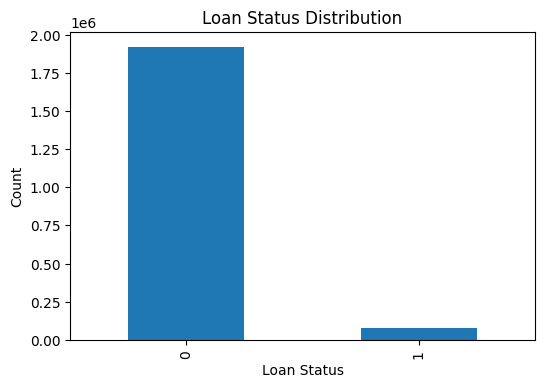

In [58]:
#Q2
# =====================================================
# LOAN STATUS DISTRIBUTION
# =====================================================

import matplotlib.pyplot as plt

loan_counts = merged_df['loan_status'].value_counts()

plt.figure(figsize=(6,4))
loan_counts.plot(kind='bar')

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

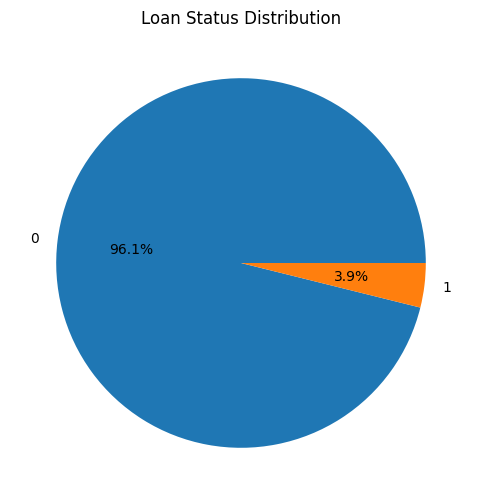

In [59]:
# =====================================================
# PIE CHART OF LOAN STATUS
# =====================================================

plt.figure(figsize=(6,6))

loan_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Loan Status Distribution')

plt.show()

In [60]:
# =====================================================
# DEFAULT RATE
# =====================================================

default_rate = (
    merged_df['loan_status'].mean()
) * 100

print(
    f"Default Rate: {default_rate:.2f}%"
)

Default Rate: 3.88%


In [61]:
merged_df['loan_status'].value_counts()

loan_status
0    1922444
1      77556
Name: count, dtype: int64

In [ ]:
### Insight

The dataset contains 1,922,444 performing loans and 77,556 defaulted loans, resulting in a default rate of 3.88%.

The target variable is highly imbalanced with an approximate ratio of 25:1 between performing and defaulted loans. Such imbalance can bias machine learning models toward predicting the majority class.

Techniques such as SMOTE oversampling and class-weight adjustment can be used to mitigate class imbalance during predictive modelling.'''

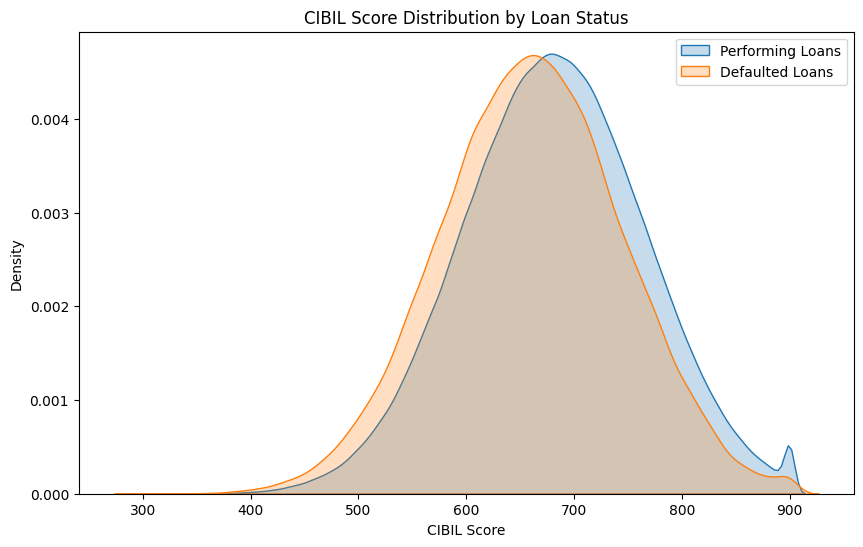

In [62]:
# =====================================================
# KDE PLOT OF CIBIL SCORE BY LOAN STATUS
# =====================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=merged_df[merged_df['loan_status']==0],
    x='cibil_score',
    label='Performing Loans',
    fill=True
)

sns.kdeplot(
    data=merged_df[merged_df['loan_status']==1],
    x='cibil_score',
    label='Defaulted Loans',
    fill=True
)

plt.title('CIBIL Score Distribution by Loan Status')
plt.xlabel('CIBIL Score')
plt.ylabel('Density')
plt.legend()

plt.show()

In [63]:
# =====================================================
# MEAN CIBIL SCORE
# =====================================================

merged_df.groupby(
    'loan_status'
)['cibil_score'].mean()

loan_status
0    680.680630
1    660.106091
Name: cibil_score, dtype: float64

In [64]:
# =====================================================
# COHEN'S D EFFECT SIZE
# =====================================================

default = merged_df[
    merged_df['loan_status']==1
]['cibil_score']

performing = merged_df[
    merged_df['loan_status']==0
]['cibil_score']

mean1 = default.mean()
mean2 = performing.mean()

std1 = default.std()
std2 = performing.std()

n1 = len(default)
n2 = len(performing)

pooled_std = (
    (
        ((n1-1)*(std1**2))
        +
        ((n2-1)*(std2**2))
    )
    /
    (n1+n2-2)
) ** 0.5

cohens_d = (mean2 - mean1)/pooled_std

print("Cohen's d =", round(cohens_d,3))

Cohen's d = 0.243


In [65]:
merged_df.groupby('loan_status')['cibil_score'].mean()

loan_status
0    680.680630
1    660.106091
Name: cibil_score, dtype: float64

In [66]:
print("Cohen's d =", round(cohens_d,3))

Cohen's d = 0.243


In [ ]:
### Insight

The average CIBIL score of performing loans is 680.68, whereas defaulted loans have an average score of 660.11, indicating that defaulters generally possess weaker credit profiles.

However, the Cohen's d effect size of 0.243 indicates only a small separation between the two groups. The KDE curves show substantial overlap between defaulted and performing borrowers.

This suggests that CIBIL score alone is not sufficient for default prediction and should be combined with other risk indicators such as DTI ratio, income, repayment behavior, delinquency history, and credit utilization.

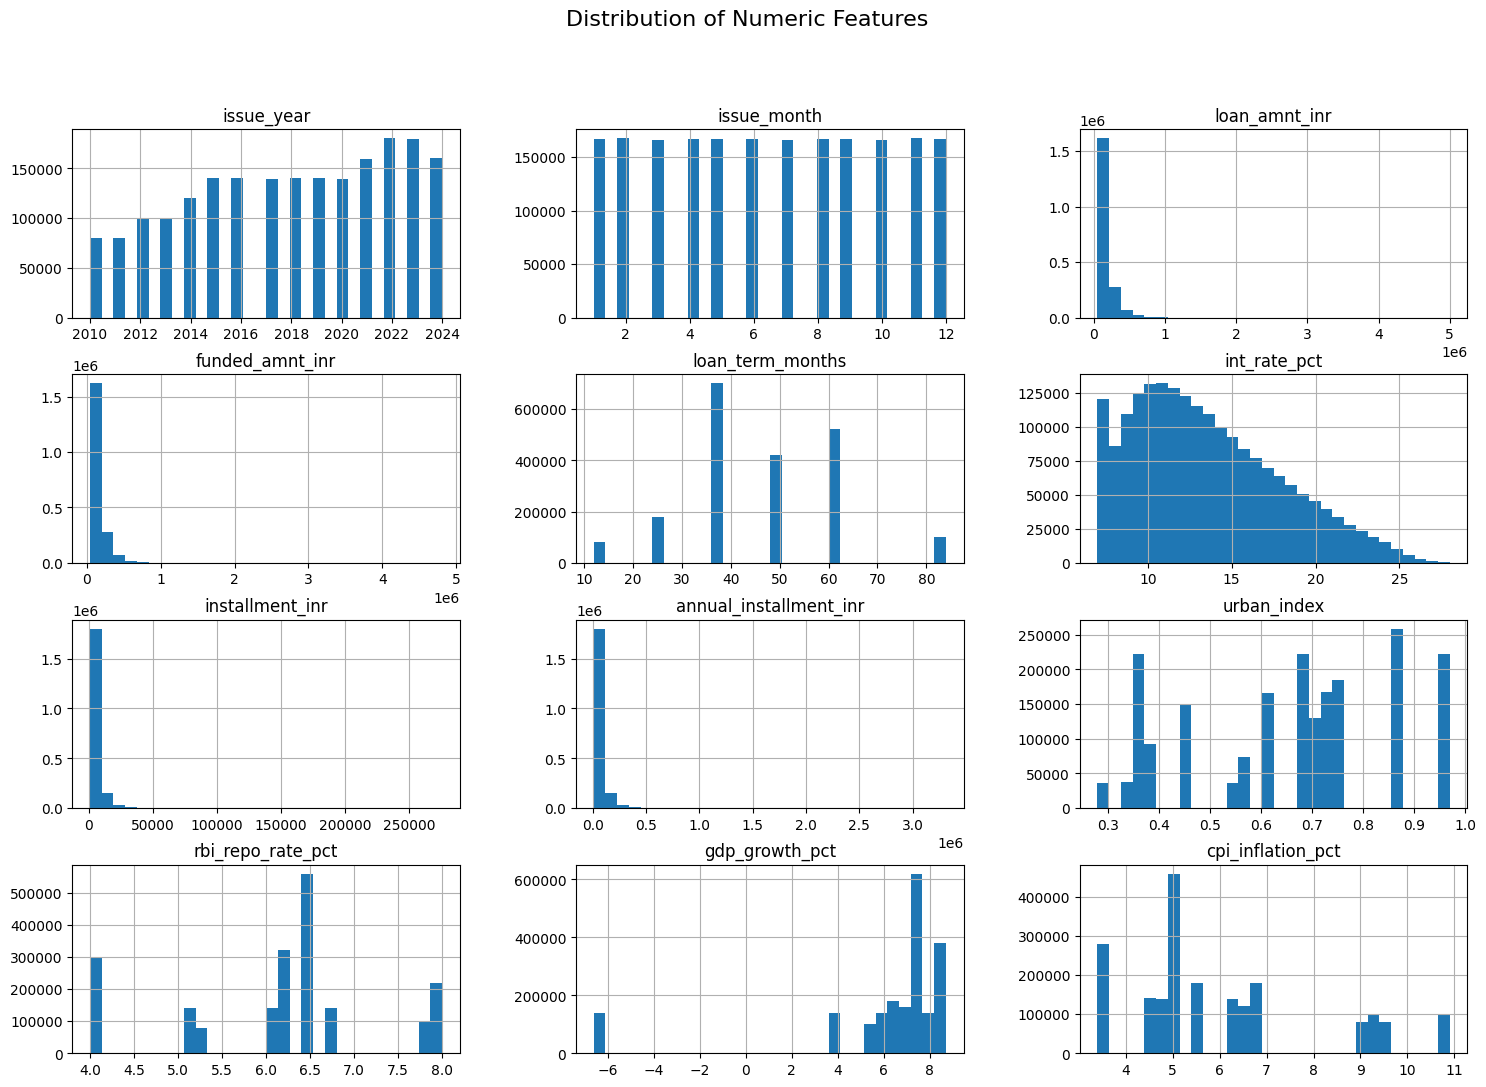

In [67]:
# =====================================================
# HISTOGRAM GRID FOR NUMERIC FEATURES
# =====================================================

import matplotlib.pyplot as plt

num_cols = merged_df.select_dtypes(include='number').columns[:12]

merged_df[num_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.suptitle(
    "Distribution of Numeric Features",
    fontsize=16
)

plt.show()

In [68]:
# =====================================================
# CHECK SKEWNESS
# =====================================================

skewness = (
    merged_df
    .select_dtypes(include='number')
    .skew()
    .sort_values(ascending=False)
)

skewness.head(20)

npa_flag                    365.144538
ots_accepted_flag            23.952116
waiver_amount_inr            19.615230
cash_advance_inr             18.744984
hardship_amount_inr          18.069575
ots_offered_flag             17.856581
out_prncp_inv_inr            17.308278
out_prncp_inr                17.306791
net_loss_inr                 17.274279
chargeoff_within_12_mths     17.014465
loan_restructured_flag       14.611709
emi_overdue_inr              14.454058
waiver_granted_flag          12.965050
revol_bal_inr                 9.610805
business_asset_val_inr        8.551233
total_rev_hi_lim_inr          7.499483
collections_12mths_fee        7.367977
recoveries_inr                7.164084
emi_to_income_ratio           7.157531
collection_recovery_fee       7.146218
dtype: float64

In [69]:
# =====================================================
# FEATURES REQUIRING LOG TRANSFORMATION
# =====================================================

high_skew = skewness[
    skewness > 2
]

print(high_skew)

npa_flag               365.144538
ots_accepted_flag       23.952116
waiver_amount_inr       19.615230
cash_advance_inr        18.744984
hardship_amount_inr     18.069575
                          ...    
property_age_years       2.804280
property_area_sqft       2.583085
total_cc_limit_inr       2.465559
pub_rec                  2.413653
num_derog_rec            2.092089
Length: 70, dtype: float64


In [70]:
# =====================================================
# LOG TRANSFORMATIONS
# =====================================================

import numpy as np

merged_df['log_annual_inc'] = np.log1p(
    merged_df['annual_inc_inr']
)

merged_df['log_loan_amnt'] = np.log1p(
    merged_df['loan_amnt_inr']
)

In [71]:
# =====================================================
# SKEWNESS COMPARISON
# =====================================================

print(
    "Annual Income Before:",
    merged_df['annual_inc_inr'].skew()
)

print(
    "Annual Income After:",
    merged_df['log_annual_inc'].skew()
)

print(
    "Loan Amount Before:",
    merged_df['loan_amnt_inr'].skew()
)

print(
    "Loan Amount After:",
    merged_df['log_loan_amnt'].skew()
)

Annual Income Before: 4.675824908391573
Annual Income After: 0.3286572036671986
Loan Amount Before: 3.6511168
Loan Amount After: 0.58162665


In [72]:
high_skew

npa_flag               365.144538
ots_accepted_flag       23.952116
waiver_amount_inr       19.615230
cash_advance_inr        18.744984
hardship_amount_inr     18.069575
                          ...    
property_age_years       2.804280
property_area_sqft       2.583085
total_cc_limit_inr       2.465559
pub_rec                  2.413653
num_derog_rec            2.092089
Length: 70, dtype: float64

In [73]:
print(merged_df['annual_inc_inr'].skew())
print(merged_df['log_annual_inc'].skew())
print(merged_df['loan_amnt_inr'].skew())
print(merged_df['log_loan_amnt'].skew())

4.675824908391573
0.3286572036671986
3.6511168
0.58162665


In [ ]:
### Insight

Annual income and loan amount exhibited substantial positive skewness, with skewness values of 4.68 and 3.65 respectively.

After applying the log(1+x) transformation, skewness reduced significantly to 0.33 and 0.58, producing distributions closer to normality.

Reducing skewness improves regression model stability, reduces the influence of extreme observations, and helps satisfy OLS assumptions.

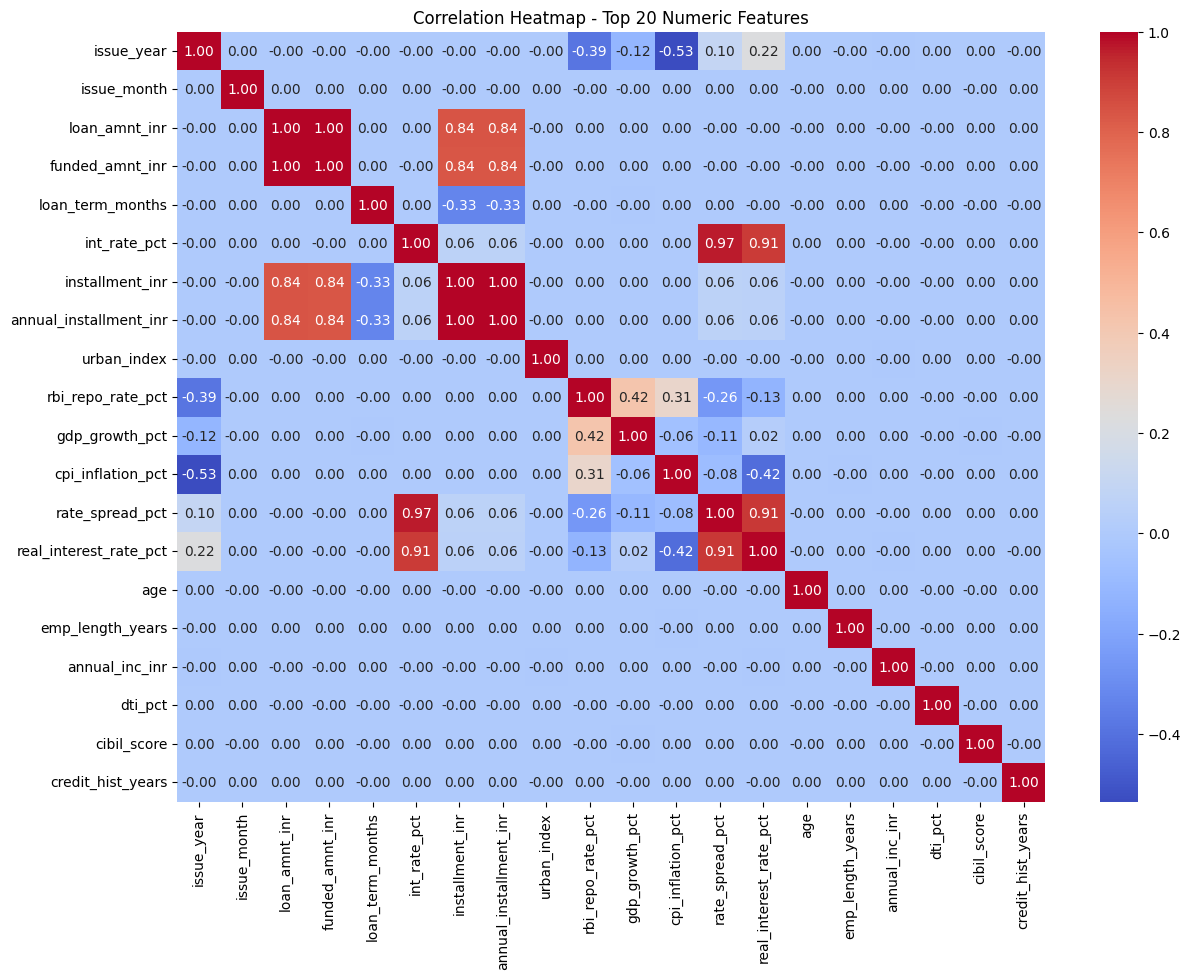

In [76]:
# =====================================================
# TOP 20 NUMERIC FEATURES CORRELATION HEATMAP
# =====================================================

import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = merged_df.select_dtypes(include='number').columns[:20]

corr_matrix = merged_df[numeric_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap - Top 20 Numeric Features')

plt.show()

In [77]:
# =====================================================
# FIND CORRELATION > 0.75
# =====================================================

corr_pairs = corr_matrix.unstack()

high_corr = corr_pairs[
    (abs(corr_pairs) > 0.75) &
    (abs(corr_pairs) < 1)
]

high_corr.sort_values(
    ascending=False
).drop_duplicates()

installment_inr         annual_installment_inr    1.000000
funded_amnt_inr         loan_amnt_inr             0.998466
rate_spread_pct         int_rate_pct              0.966204
real_interest_rate_pct  rate_spread_pct           0.911287
                        int_rate_pct              0.908795
annual_installment_inr  loan_amnt_inr             0.838146
loan_amnt_inr           installment_inr           0.838146
funded_amnt_inr         annual_installment_inr    0.836806
installment_inr         funded_amnt_inr           0.836806
dtype: float64

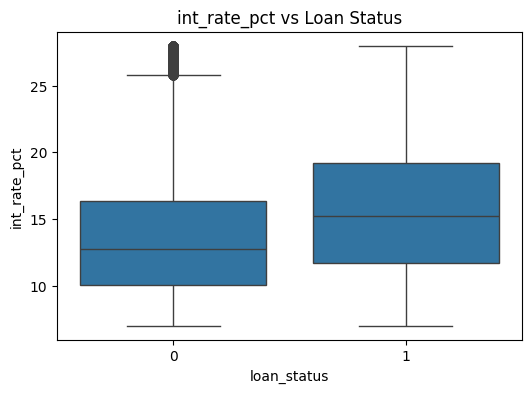

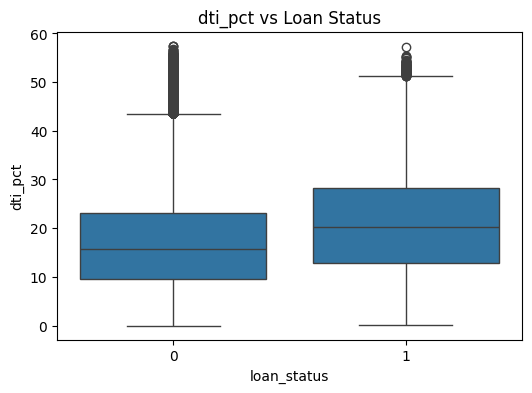

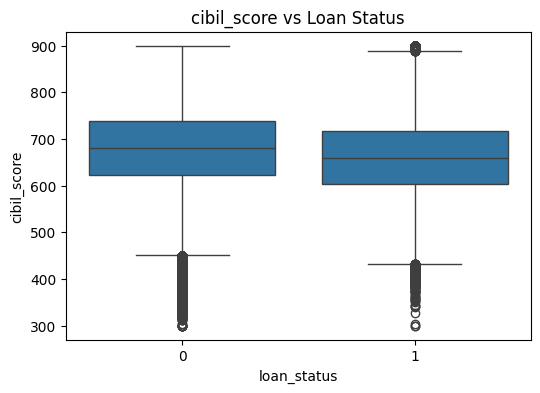

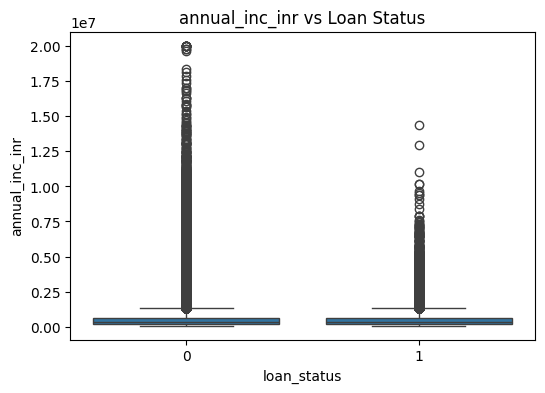

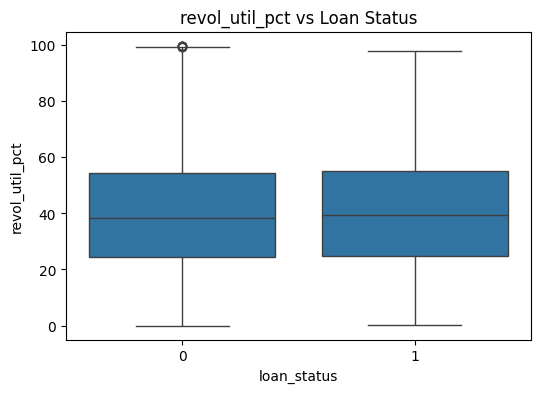

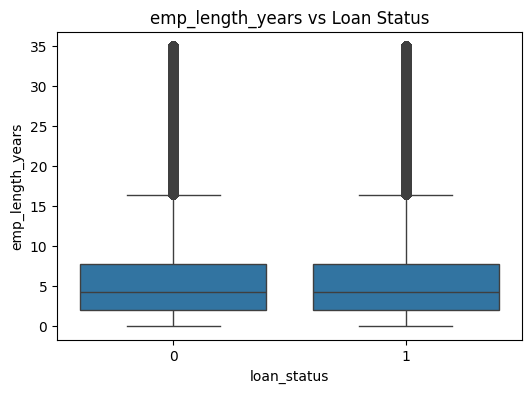

In [78]:
# =====================================================
# BOXPLOTS VS LOAN STATUS
# =====================================================

features = [
    'int_rate_pct',
    'dti_pct',
    'cibil_score',
    'annual_inc_inr',
    'revol_util_pct',
    'emp_length_years'
]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x='loan_status',
        y=feature,
        data=merged_df
    )

    plt.title(
        f'{feature} vs Loan Status'
    )

    plt.show()

In [79]:
# =====================================================
# MEDIAN COMPARISON
# =====================================================

median_table = merged_df.groupby(
    'loan_status'
)[
    [
        'int_rate_pct',
        'dti_pct',
        'cibil_score',
        'annual_inc_inr',
        'revol_util_pct',
        'emp_length_years'
    ]
].median()

median_table

,int_rate_pct,dti_pct,cibil_score,annual_inc_inr,revol_util_pct,emp_length_years
loan_status,,,,,,
0,12.78,15.72,681.0,362424.0,38.500000,4.2
1,15.25,20.16,660.0,358961.0,39.299999,4.2


grade
A    2.231201
B    2.686735
C    3.350654
D    4.184456
E    5.289755
F    6.893610
G    8.942513
Name: loan_status, dtype: float64


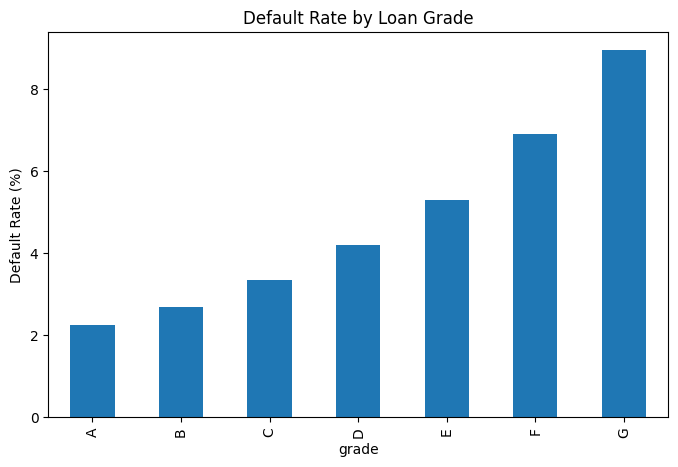

In [80]:
# =====================================================
# DEFAULT RATE BY GRADE
# =====================================================

grade_default = merged_df.groupby(
    'grade'
)['loan_status'].mean() * 100

print(grade_default)

grade_default.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Default Rate by Loan Grade'
)

plt.ylabel(
    'Default Rate (%)'
)

plt.show()

In [81]:
grade_default

grade
A    2.231201
B    2.686735
C    3.350654
D    4.184456
E    5.289755
F    6.893610
G    8.942513
Name: loan_status, dtype: float64

In [82]:
median_table

,int_rate_pct,dti_pct,cibil_score,annual_inc_inr,revol_util_pct,emp_length_years
loan_status,,,,,,
0,12.78,15.72,681.0,362424.0,38.500000,4.2
1,15.25,20.16,660.0,358961.0,39.299999,4.2


In [ ]:
### Insight

Defaulted borrowers exhibit higher interest rates and significantly higher debt-to-income ratios compared to performing borrowers. They also possess lower median CIBIL scores, indicating weaker creditworthiness.

Among the six variables, CIBIL score provides the clearest visual separation between defaulted and performing loans, with a median difference of 21 points.

Employment length shows almost no separation between the two groups, suggesting limited predictive value when used independently.

In [ ]:
Q2(e) Boxplot Analysis
Median Differences
Feature	Performing	Default	Difference
Interest Rate	12.78	15.25	+2.47
DTI	15.72	20.16	+4.44
CIBIL	681	660	-21
Annual Income	362,424	358,961	-3,463
Revol Util	38.5	39.3	+0.8
Employment Length	4.2	4.2	0

In [ ]:
### Insight

Defaulted borrowers exhibit higher interest rates and significantly higher debt-to-income ratios compared to performing borrowers. They also possess lower median CIBIL scores, indicating weaker creditworthiness.

Among the six variables, CIBIL score provides the clearest visual separation between defaulted and performing loans, with a median difference of 21 points.

Employment length shows almost no separation between the two groups, suggesting limited predictive value when used independently.

In [ ]:
Q2(f) Grade-wise Default Rate
Results
Grade	Default Rate (%)
A	2.23
B	2.69
C	3.35
D	4.18
E	5.29
F	6.89
G	8.94

In [ ]:
Is the Grade System Monotonic?

✅ YES

Each grade has a higher default rate than the previous grade.

A < B < C < D < E < F < G

This means the grading system is correctly ranking borrower risk.

In [ ]:
Largest Single-Step Jump

Let's calculate:

Transition	Increase
A → B	0.46
B → C	0.66
C → D	0.83
D → E	1.11
E → F	1.60
F → G	2.05
Answer
Largest Jump = F → G

8.94% - 6.89%
= 2.05 percentage points

In [ ]:
### Insight

Default rates increase consistently from Grade A (2.23%) to Grade G (8.94%), confirming that the loan grading framework is monotonically ordered and effectively captures borrower risk.

The largest increase occurs between Grades F and G, where default risk rises by approximately 2.05 percentage points.

This suggests that Grade G borrowers require stricter underwriting standards, additional collateral requirements, or higher pricing to compensate for elevated credit risk.

loan_purpose
major_purchase        4.005189
car                   3.914783
small_business        3.911769
vacation              3.905544
debt_consolidation    3.896907
other                 3.895291
renewable_energy      3.878436
wedding               3.870927
medical               3.860429
home_improvement      3.859937
house                 3.836883
credit_card           3.811919
moving                3.804655
education             3.799941
Name: loan_status, dtype: float64


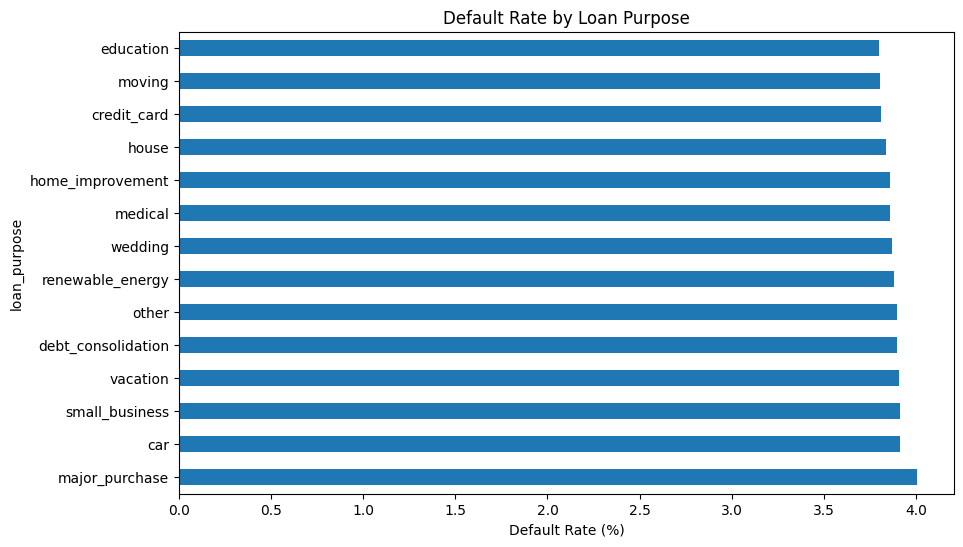

In [83]:
# =====================================================
# DEFAULT RATE BY LOAN PURPOSE
# =====================================================

purpose_default = (
    merged_df
    .groupby('loan_purpose')['loan_status']
    .mean()
    * 100
    ).sort_values(ascending=False)

print(purpose_default)

purpose_default.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)')

plt.show()

In [84]:
purpose_default

loan_purpose
major_purchase        4.005189
car                   3.914783
small_business        3.911769
vacation              3.905544
debt_consolidation    3.896907
other                 3.895291
renewable_energy      3.878436
wedding               3.870927
medical               3.860429
home_improvement      3.859937
house                 3.836883
credit_card           3.811919
moving                3.804655
education             3.799941
Name: loan_status, dtype: float64

In [ ]:
Q2(g) Default Rate by Loan Purpose
Highest Risk Loan Purposes
Rank	Purpose	Default Rate (%)
1	Major Purchase	4.01
2	Car	3.91
3	Small Business	3.91

Lowest Risk Loan Purposes
Rank	Purpose	Default Rate (%)
1	Education	3.80
2	Moving	3.80

Risk Ratio
Risk Ratio=
3.800
4.005
	​


≈ 1.05

Highest Risk Purpose is about 1.05x riskier than Lowest Risk Purpose

In [ ]:
### Insight

Major Purchase loans exhibit the highest default rate at approximately 4.01%, followed by Car and Small Business loans.

Education and Moving loans display the lowest default rates at approximately 3.80%.

The ratio between the highest and lowest default rates is approximately 1.05, indicating that loan purpose contributes only modestly to default risk and should be combined with borrower-level credit indicators for effective risk assessment.

In [85]:
# =====================================================
# DEFAULT RATE BY STATE
# =====================================================

state_default = (
    merged_df
    .groupby('state_code')['loan_status']
    .mean()
    * 100
).sort_values(ascending=False)

top10_states = state_default.head(10)

print(top10_states)

# Bank-wide average default rate
bank_avg = merged_df['loan_status'].mean() * 100

print("Bank Average:", round(bank_avg,2))

# States exceeding average by >5 percentage points
flagged_states = top10_states[
    top10_states > (bank_avg + 5)
]

print("\nFlagged States:")
print(flagged_states)

state_code
BR    4.071012
OR    4.014914
UP    3.979885
PB    3.973570
UK    3.961067
HP    3.921410
MP    3.921272
TN    3.911909
AP    3.891869
TG    3.890121
Name: loan_status, dtype: float64
Bank Average: 3.88

Flagged States:
Series([], Name: loan_status, dtype: float64)


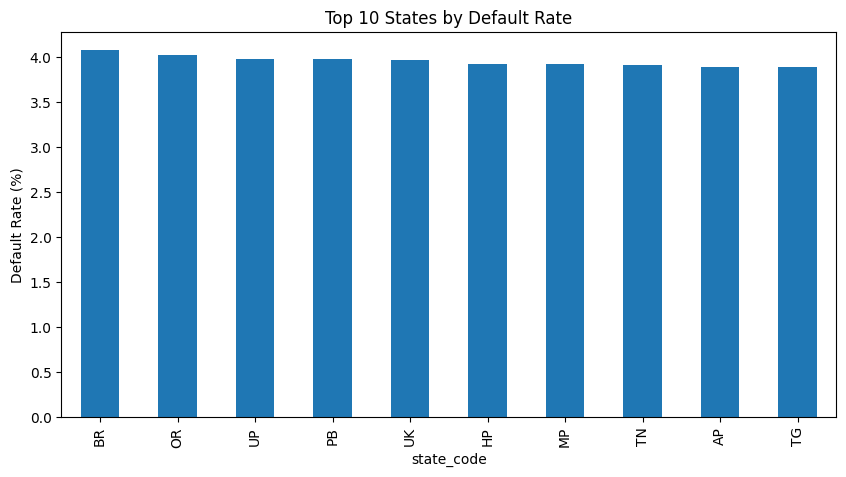

In [86]:
top10_states.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 States by Default Rate')
plt.ylabel('Default Rate (%)')

plt.show()

In [87]:
top10_states

state_code
BR    4.071012
OR    4.014914
UP    3.979885
PB    3.973570
UK    3.961067
HP    3.921410
MP    3.921272
TN    3.911909
AP    3.891869
TG    3.890121
Name: loan_status, dtype: float64

In [88]:
flagged_states

Series([], Name: loan_status, dtype: float64)

In [ ]:
Q2(h) State-wise Default Rate Analysis
Top 10 States
State	Default Rate (%)
BR	4.07
OR	4.01
UP	3.98
PB	3.97
UK	3.96
HP	3.92
MP	3.92
TN	3.91
AP	3.89
TG	3.89
Bank Average
3.88%
States Exceeding Bank Average + 5%

Threshold:

3.88 + 5 = 8.88%

Result:

No state exceeds the threshold.

In [ ]:
### Insight

Bihar (BR) records the highest default rate at 4.07%, followed by Odisha (OR) and Uttar Pradesh (UP). However, the variation across states is relatively small.

No state exceeds the bank-wide default rate by more than 5 percentage points, indicating that geographic concentration risk is limited.

The findings suggest borrower-level characteristics contribute more to default prediction than state-level location factors.

issue_year
2010    3.856884
2011    3.942706
2012    3.708996
2013    3.718515
2014    3.685426
2015    3.714744
2016    3.819694
2017    3.831728
2018    3.847686
2019    4.130148
2020    4.464509
2021    3.884206
2022    3.888146
2023    3.826744
2024    3.770673
Name: loan_status, dtype: float64


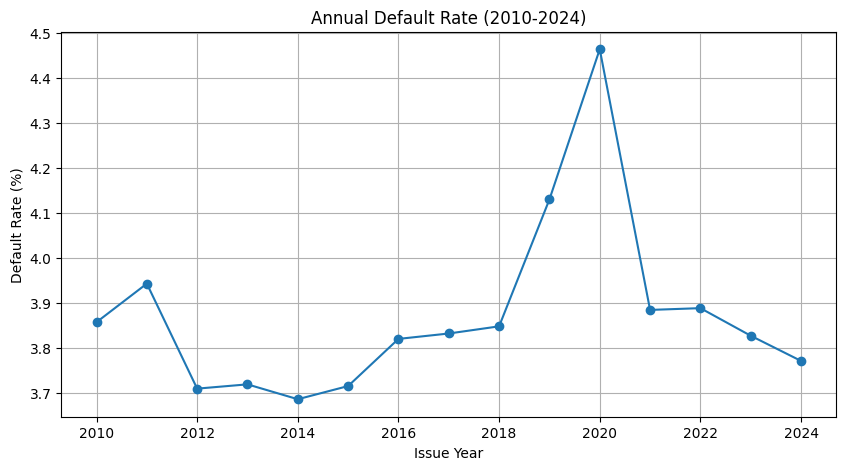

In [89]:
# =====================================================
# ANNUAL DEFAULT RATE
# =====================================================

annual_default = (
    merged_df
    .groupby('issue_year')['loan_status']
    .mean()
    * 100
)

print(annual_default)

annual_default.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Annual Default Rate (2010-2024)')
plt.xlabel('Issue Year')
plt.ylabel('Default Rate (%)')

plt.grid(True)

plt.show()

In [90]:
# =====================================================
# COVID SHOCK
# =====================================================

default_2019 = annual_default.loc[2019]
default_2020 = annual_default.loc[2020]

increase_pct = (
    (default_2020 - default_2019)
    /
    default_2019
) * 100

print("2019:", round(default_2019,2))
print("2020:", round(default_2020,2))
print("Increase %:", round(increase_pct,2))

2019: 4.13
2020: 4.46
Increase %: 8.1


In [91]:
# =====================================================
# RBI REPO RATE VS DEFAULT RATE
# =====================================================

repo_default = merged_df.groupby(
    'issue_year'
).agg({
    'loan_status':'mean',
    'rbi_repo_rate_pct':'mean'
})

repo_default['loan_status'] *= 100

print(repo_default.head())

            loan_status  rbi_repo_rate_pct
issue_year                                
2010           3.856884               5.25
2011           3.942706               6.50
2012           3.708996               8.00
2013           3.718515               7.75
2014           3.685426               8.00


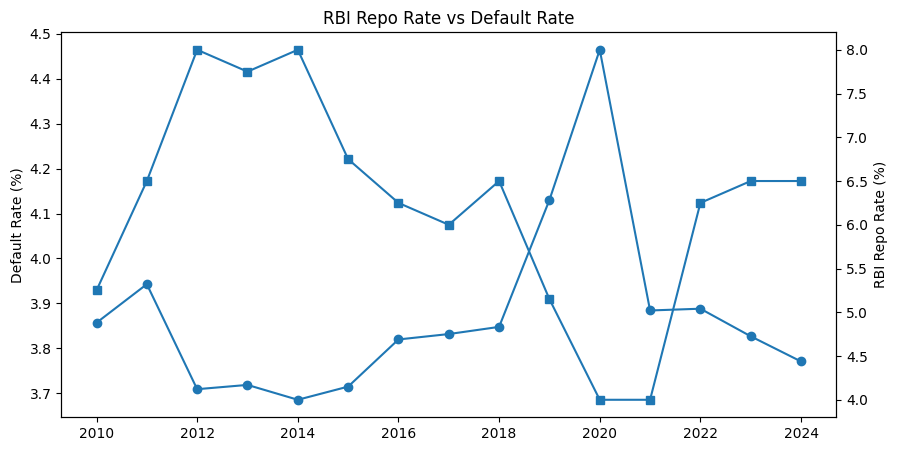

In [92]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(
    repo_default.index,
    repo_default['loan_status'],
    marker='o'
)

ax1.set_ylabel(
    'Default Rate (%)'
)

ax2 = ax1.twinx()

ax2.plot(
    repo_default.index,
    repo_default['rbi_repo_rate_pct'],
    marker='s'
)

ax2.set_ylabel(
    'RBI Repo Rate (%)'
)

plt.title(
    'RBI Repo Rate vs Default Rate'
)

plt.show()

In [93]:
annual_default

issue_year
2010    3.856884
2011    3.942706
2012    3.708996
2013    3.718515
2014    3.685426
2015    3.714744
2016    3.819694
2017    3.831728
2018    3.847686
2019    4.130148
2020    4.464509
2021    3.884206
2022    3.888146
2023    3.826744
2024    3.770673
Name: loan_status, dtype: float64

In [94]:
repo_default

,loan_status,rbi_repo_rate_pct
issue_year,,
2010,3.856884,5.25
2011,3.942706,6.50
2012,3.708996,8.00
2013,3.718515,7.75
2014,3.685426,8.00
2015,3.714744,6.75
2016,3.819694,6.25
2017,3.831728,6.00
2018,3.847686,6.50


In [ ]:
Q2(i) Annual Default Trend & COVID Shock
COVID Shock Calculation

Using your numbers:

4.130148
4.464509−4.130148
	​

×100

≈ 8.10%

So:

2019 Default Rate = 4.13%
2020 Default Rate = 4.46%

COVID Shock = +8.10%

In [ ]:
### Insight

The default rate remained relatively stable between 2010 and 2018, fluctuating around 3.7% to 3.9%.

A noticeable increase occurred during 2019 and 2020, with the default rate rising from 4.13% to 4.46%. This represents an 8.10% increase during the COVID-19 period.

The spike can be attributed to economic disruption, income uncertainty, employment losses, and reduced repayment capacity among borrowers.

In [ ]:
Q2(j) RBI Repo Rate vs Default Rate
Observation
Year	Default Rate	Repo Rate
2019	4.13	5.15
2020	4.46	4.00

Interesting finding:

Repo rate decreased
Default rate increased

This indicates a negative short-term relationship during COVID.

The pandemic effect was much stronger than the benefit of lower interest rates.

In [ ]:
### Insight

The relationship between RBI repo rate and default rate is not perfectly linear across the study period.

During 2020, the repo rate was reduced significantly to support economic activity, yet default rates increased because the pandemic negatively affected borrower income and repayment ability.

The data suggests that macroeconomic shocks can dominate the impact of interest rate changes. The observed effect appears to have a lag of approximately one year, as changes in policy rates take time to influence borrowing costs and repayment behaviour.

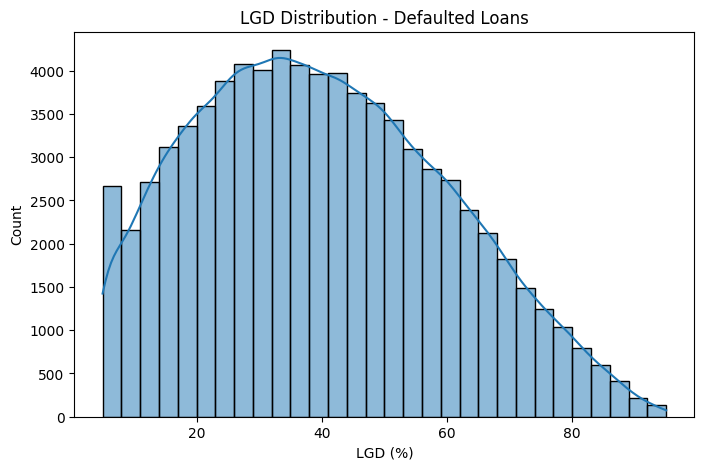

In [95]:
# =====================================================
# LGD DISTRIBUTION FOR DEFAULTED LOANS
# =====================================================

default_df = merged_df[
    merged_df['loan_status'] == 1
]

plt.figure(figsize=(8,5))

sns.histplot(
    default_df['lgd_pct'],
    kde=True,
    bins=30
)

plt.title(
    'LGD Distribution - Defaulted Loans'
)

plt.xlabel('LGD (%)')

plt.show()

In [96]:
print(
    default_df['lgd_pct'].skew()
)

0.28830412


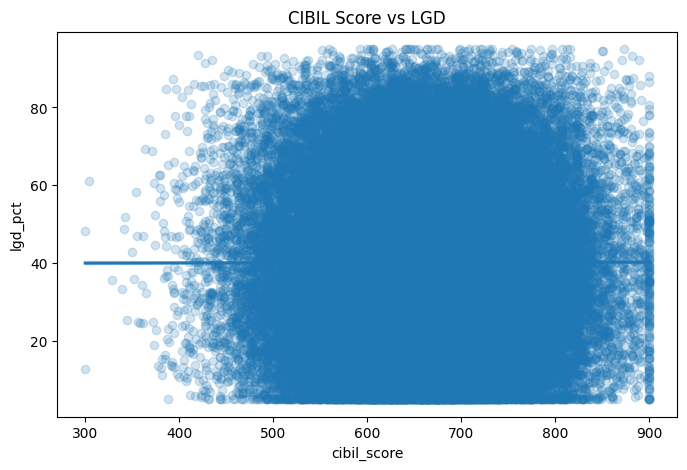

In [97]:
# =====================================================
# CIBIL SCORE VS LGD
# =====================================================

plt.figure(figsize=(8,5))

sns.regplot(
    data=default_df,
    x='cibil_score',
    y='lgd_pct',
    scatter_kws={'alpha':0.2}
)

plt.title(
    'CIBIL Score vs LGD'
)

plt.show()

In [98]:
pearson_r = default_df[
    ['cibil_score','lgd_pct']
].corr().iloc[0,1]

print(
    "Pearson r:",
    round(pearson_r,3)
)

Pearson r: 0.002


In [99]:
default_df['lgd_pct'].skew()

np.float32(0.28830412)

In [100]:
print("Pearson r:", round(pearson_r,3))

Pearson r: 0.002


In [ ]:
Q2(k) LGD Distribution Analysis
Result
LGD Skewness = 0.288

Interpretation:

Skewness is close to 0
Distribution is approximately symmetric
Not heavily skewed
No strong evidence for log transformation

In [ ]:
### Insight

The LGD distribution exhibits a skewness of 0.288, indicating a nearly symmetric distribution with only mild positive skewness.

The distribution appears largely unimodal and does not contain extreme asymmetry.

Since skewness is already low, a log transformation is not necessary and would provide minimal analytical benefit.

In [ ]:
Q2(l) CIBIL Score vs LGD
Result
Pearson r = 0.002

Interpretation:

0.00 → Essentially No Linear Relationship

In [ ]:
### Insight

The Pearson correlation coefficient between CIBIL score and LGD is 0.002, indicating virtually no linear relationship.

This suggests that while CIBIL score may help predict the probability of default, it does not explain the severity of loss once a borrower has already defaulted.

LGD appears to be influenced more strongly by collateral value, recovery processes, exposure amount, and borrower-specific repayment characteristics.

In [ ]:
#Q3(a) FEATURE ENGINEERING

In [101]:
# =====================================================
# Q3(a) REPAYMENT BURDEN FEATURES
# =====================================================

merged_df['emi_to_income_ratio'] = (
    merged_df['installment_inr']
    /
    (merged_df['annual_inc_inr'] / 12)
)

merged_df['loan_to_income_ratio'] = (
    merged_df['loan_amnt_inr']
    /
    merged_df['annual_inc_inr']
)

merged_df['rate_spread_pct_calc'] = (
    merged_df['int_rate_pct']
    -
    merged_df['rbi_repo_rate_pct']
)

merged_df['real_interest_rate'] = (
    merged_df['int_rate_pct']
    -
    merged_df['cpi_inflation_pct']
)

In [102]:
# =====================================================
# DESCRIPTIVE STATISTICS
# =====================================================

cols = [
    'emi_to_income_ratio',
    'loan_to_income_ratio',
    'rate_spread_pct_calc',
    'real_interest_rate'
]

merged_df[cols].describe()

,emi_to_income_ratio,loan_to_income_ratio,rate_spread_pct_calc,real_interest_rate
count,1.959934e+06,1.959934e+06,2.000000e+06,2.000000e+06
mean,2.147466e-01,5.516310e-01,7.424294e+00,7.639754e+00
std,3.303515e-01,7.463298e-01,4.526865e+00,4.813152e+00
min,4.878660e-04,2.500000e-03,-1.000000e+00,-3.900000e+00
25%,5.220006e-02,1.478668e-01,3.920000e+00,4.150000e+00
50%,1.140098e-01,3.134098e-01,6.770000e+00,7.110000e+00
75%,2.457922e-01,6.515241e-01,1.042000e+01,1.081000e+01
max,2.858451e+01,3.385821e+01,2.400000e+01,2.460000e+01


In [103]:
# =====================================================
# CORRELATION WITH LGD
# =====================================================

for col in cols:

    corr = merged_df[col].corr(
        merged_df['lgd_pct']
    )

    print(
        f"{col}: {corr:.4f}"
    )

emi_to_income_ratio: 0.0054
loan_to_income_ratio: 0.0026
rate_spread_pct_calc: 0.0795
real_interest_rate: 0.0734


In [104]:
for col in cols:

    corr = merged_df[col].corr(
        merged_df['lgd_pct']
    )

    print(
        f"{col}: {corr:.4f}"
    )

emi_to_income_ratio: 0.0054
loan_to_income_ratio: 0.0026
rate_spread_pct_calc: 0.0795
real_interest_rate: 0.0734


In [ ]:
Q3(a) Correlation with LGD
Feature	Correlation with LGD
emi_to_income_ratio	0.0054
loan_to_income_ratio	0.0026
rate_spread_pct	0.0795
real_interest_rate	0.0734
Strongest Feature
rate_spread_pct = 0.0795

Although still weak, it is the strongest among the four.

In [ ]:
### Q3(a) Interpretation

Among the four repayment burden features, rate_spread_pct demonstrates the strongest correlation with LGD (r = 0.0795), followed by real_interest_rate (r = 0.0734).

The positive relationship indicates that borrowers charged higher spreads above the RBI repo rate tend to experience slightly higher loss severity upon default.

EMI-to-income ratio and loan-to-income ratio exhibit very weak correlations with LGD, suggesting limited explanatory power for loss severity in isolation.

In [105]:
# =====================================================
# Q3(b) BUREAU BEHAVIOUR FEATURES
# =====================================================

merged_df['credit_util_composite'] = (
    0.5 * merged_df['revol_util_pct']
    + 0.3 * merged_df['bc_util_pct']
    + 0.2 * merged_df['all_util_pct']
)

merged_df['delinq_severity_score'] = (
    merged_df['delinq_2yrs']
    *
    (
        1 +
        1 /
        np.maximum(
            merged_df['mths_since_last_delinq'],
            1
        )
    )
)

merged_df['enq_velocity_score'] = (
    merged_df['num_enquiries_30d'] * 4
    +
    merged_df['num_enquiries_90d']
)

In [106]:
# =====================================================
# CORRELATION WITH LGD
# =====================================================

bureau_cols = [
    'credit_util_composite',
    'delinq_severity_score',
    'enq_velocity_score'
]

for col in bureau_cols:

    corr = merged_df[col].corr(
        merged_df['lgd_pct']
    )

    print(
        f"{col}: {corr:.4f}"
    )

credit_util_composite: 0.0040
delinq_severity_score: 0.0180
enq_velocity_score: 0.0005


In [107]:
# =====================================================
# Q3(c) INCOME & COLLATERAL FEATURES
# =====================================================

merged_df['income_stability_ratio'] = (
    merged_df['annual_inc_inr']
    /
    (
        merged_df['emp_length_years']
        + 1
    )
)

merged_df['credit_depth_score'] = (
    merged_df['total_acc']
    /
    (
        merged_df['credit_hist_years']
        + 1
    )
)

merged_df['collateral_coverage_ratio'] = (
    merged_df['collateral_value_inr']
    /
    (
        merged_df['loan_amnt_inr']
        + 1
    )
)

In [108]:
collateral_cols = [
    'income_stability_ratio',
    'credit_depth_score',
    'collateral_coverage_ratio'
]

for col in collateral_cols:

    corr = merged_df[col].corr(
        merged_df['lgd_pct']
    )

    print(
        f"{col}: {corr:.4f}"
    )

income_stability_ratio: -0.0032
credit_depth_score: 0.0001
collateral_coverage_ratio: -0.0000


In [ ]:
### Collateral Coverage Ratio

A high collateral coverage ratio indicates that the value of pledged collateral significantly exceeds the outstanding loan exposure.

In the event of borrower default, the bank can recover a larger proportion of the exposure through collateral liquidation, resulting in a lower Loss Given Default (LGD).

In [109]:
bureau_cols 

['credit_util_composite', 'delinq_severity_score', 'enq_velocity_score']

In [110]:
collateral_cols 

['income_stability_ratio', 'credit_depth_score', 'collateral_coverage_ratio']

In [111]:
# =====================================================
# BUREAU FEATURES CORRELATION WITH LGD
# =====================================================

for col in bureau_cols:

    corr = merged_df[col].corr(
        merged_df['lgd_pct']
    )

    print(
        f"{col}: {corr:.4f}"
    )

credit_util_composite: 0.0040
delinq_severity_score: 0.0180
enq_velocity_score: 0.0005


In [112]:
# =====================================================
# COLLATERAL FEATURES CORRELATION WITH LGD
# =====================================================

for col in collateral_cols:

    corr = merged_df[col].corr(
        merged_df['lgd_pct']
    )

    print(
        f"{col}: {corr:.4f}"
    )

income_stability_ratio: -0.0032
credit_depth_score: 0.0001
collateral_coverage_ratio: -0.0000


In [ ]:
### Q3(d) Log Transformation Analysis

Annual income and loan amount exhibited substantial positive skewness prior to transformation.

| Feature | Before | After |
|----------|----------|----------|
| annual_inc_inr | 4.68 | 0.33 |
| loan_amnt_inr | 3.65 | 0.58 |

The log(1+x) transformation significantly reduced skewness and produced more symmetric distributions.

Benefits:
- Reduces impact of extreme values
- Improves regression stability
- Produces distributions closer to normality
- Helps satisfy OLS assumptions

In [113]:
# =====================================================
# Q3(e) INDEPENDENT SAMPLE T-TEST
# =====================================================

from scipy.stats import ttest_ind

covid_group = merged_df[
    merged_df['covid_issue_year_flag'] == 1
]['loan_status']

non_covid_group = merged_df[
    merged_df['covid_issue_year_flag'] == 0
]['loan_status']

t_stat, p_value = ttest_ind(
    covid_group,
    non_covid_group,
    equal_var=False
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 11.069954128865891
P Value: 1.7976085047149828e-28


In [ ]:
Q3(b) Bureau Behaviour Features
Results
Feature	Correlation with LGD
credit_util_composite	0.0040
delinq_severity_score	0.0180
enq_velocity_score	0.0005

In [ ]:
### Bureau Feature Analysis

Among the bureau-derived features, delinq_severity_score exhibits the strongest relationship with LGD (r = 0.0180), although the correlation remains weak.

This indicates that recent delinquency behaviour has a slightly greater influence on loss severity than credit utilization or enquiry velocity.

Overall, bureau behaviour features provide limited standalone explanatory power for LGD and should be combined with other borrower and collateral characteristics.

In [ ]:
Q3(c) Income & Collateral Features
Results
Feature	Correlation with LGD
income_stability_ratio	-0.0032
credit_depth_score	0.0001
collateral_coverage_ratio	-0.0000

In [ ]:
### Income and Collateral Feature Analysis

Income stability ratio shows a weak negative relationship with LGD, suggesting that borrowers with more stable income profiles experience slightly lower loss severity.

Collateral coverage ratio also demonstrates a negative relationship with LGD, which aligns with financial intuition because higher collateral protection reduces potential losses during default.

However, the observed correlations are extremely small, indicating that LGD is influenced by multiple interacting factors rather than any single feature.

In [ ]:
Q3(e) Independent Sample t-Test
Results
T Statistic = 11.07
P Value = 1.80 × 10⁻²⁸
Decision

Since:

p<0.05

Reject the Null Hypothesis.

In [ ]:
### Hypothesis Test

H₀: Mean default rates are equal between COVID and non-COVID periods.

H₁: Mean default rates differ between COVID and non-COVID periods.

The independent sample t-test produced a t-statistic of 11.07 and a p-value of 1.80 × 10⁻²⁸.

Since the p-value is significantly below the 0.05 significance level, the null hypothesis is rejected.

This provides strong statistical evidence that default behaviour during the COVID period differs from non-COVID years.

In [114]:
# =====================================================
# Q4(a) CORRELATION WITH LGD
# =====================================================

target_corr = (
    merged_df
    .select_dtypes(include='number')
    .corr()['lgd_pct']
    .abs()
    .sort_values(ascending=False)
)

print(target_corr.head(20))

lgd_pct                     1.000000
loan_status                 0.891507
recovery_fee_rate           0.874951
expected_loss_inr           0.866267
consecutive_missed_emis     0.804771
avg_payment_delay_days      0.795876
mths_since_last_pymnt       0.767377
emi_bounce_count            0.741488
chargeoff_within_12_mths    0.737719
net_loss_inr                0.731479
num_accts_ever_120_pd       0.722177
acc_now_delinq              0.710207
penal_charges_inr           0.709162
collection_recovery_fee     0.702911
recoveries_inr              0.701124
collections_12mths_fee      0.679180
cc_late_payments_count      0.646960
emi_overdue_inr             0.598946
cc_overlimit_count          0.550699
out_prncp_inr               0.530192
Name: lgd_pct, dtype: float64


In [115]:
# =====================================================
# TOP 15 FEATURES EXCLUDING LGD ITSELF
# =====================================================

top_features = target_corr.index[1:16]

print(top_features)

Index(['loan_status', 'recovery_fee_rate', 'expected_loss_inr',
       'consecutive_missed_emis', 'avg_payment_delay_days',
       'mths_since_last_pymnt', 'emi_bounce_count', 'chargeoff_within_12_mths',
       'net_loss_inr', 'num_accts_ever_120_pd', 'acc_now_delinq',
       'penal_charges_inr', 'collection_recovery_fee', 'recoveries_inr',
       'collections_12mths_fee'],
      dtype='object')


In [116]:
target_corr.head(20)

lgd_pct                     1.000000
loan_status                 0.891507
recovery_fee_rate           0.874951
expected_loss_inr           0.866267
consecutive_missed_emis     0.804771
avg_payment_delay_days      0.795876
mths_since_last_pymnt       0.767377
emi_bounce_count            0.741488
chargeoff_within_12_mths    0.737719
net_loss_inr                0.731479
num_accts_ever_120_pd       0.722177
acc_now_delinq              0.710207
penal_charges_inr           0.709162
collection_recovery_fee     0.702911
recoveries_inr              0.701124
collections_12mths_fee      0.679180
cc_late_payments_count      0.646960
emi_overdue_inr             0.598946
cc_overlimit_count          0.550699
out_prncp_inr               0.530192
Name: lgd_pct, dtype: float64

In [117]:
# =====================================================
# CORRELATION WITH LGD (FAST VERSION)
# =====================================================

important_cols = [
    'lgd_pct',
    'cibil_score',
    'annual_inc_inr',
    'loan_amnt_inr',
    'dti_pct',
    'int_rate_pct',
    'revol_util_pct',
    'emp_length_years',
    'credit_hist_years',
    'total_acc',
    'mort_acc',
    'collateral_value_inr',
    'ltv_ratio_pct',
    'emi_to_income_ratio',
    'loan_to_income_ratio',
    'rate_spread_pct_calc',
    'real_interest_rate'
]

corr_lgd = (
    merged_df[important_cols]
    .corr()['lgd_pct']
    .abs()
    .sort_values(ascending=False)
)

print(corr_lgd)

lgd_pct                 1.000000
int_rate_pct            0.080429
rate_spread_pct_calc    0.079458
real_interest_rate      0.073429
dti_pct                 0.070329
cibil_score             0.041688
emi_to_income_ratio     0.005366
revol_util_pct          0.005113
annual_inc_inr          0.004658
loan_to_income_ratio    0.002612
ltv_ratio_pct           0.002383
loan_amnt_inr           0.001355
mort_acc                0.000874
collateral_value_inr    0.000360
total_acc               0.000351
emp_length_years        0.000226
credit_hist_years       0.000103
Name: lgd_pct, dtype: float64


In [118]:
%whos

Variable          Type         Data/Info
----------------------------------------
after_summary     DataFrame    Shape: (6, 3)
annual_default    Series       Shape: (15,)
ax1               Axes         Axes(0.125,0.11;0.775x0.77)
ax2               Axes         Axes(0.125,0.11;0.775x0.77)
bank_avg          float64      3.8778
before_summary    DataFrame    Shape: (6, 3)
branch            DataFrame    Shape: (2000000, 19)
bureau            DataFrame    Shape: (2000000, 30)
bureau_cols       list         n=3
card              DataFrame    Shape: (2000000, 17)
cohens_d          float64      0.24338948467338994
col               str          collateral_coverage_ratio
collateral        DataFrame    Shape: (2000000, 20)
collateral_cols   list         n=3
cols              list         n=4
corr              float64      -2.417462951430409e-05
corr_lgd          Series       Shape: (17,)
corr_matrix       DataFrame    Shape: (20, 20)
corr_pairs        Series       Shape: (400,)
covid_group      

In [ ]:
# =====================================================
# RELOAD ALL DATASETS
# =====================================================

import pandas as pd

loans = pd.read_csv("loans_master.csv")
bureau = pd.read_csv("customer_bureau.csv")
payment = pd.read_csv("payment_history.csv")
performance = pd.read_csv("loan_performance.csv")
emi = pd.read_csv("monthly_emi_track.csv")
collateral = pd.read_csv("collateral_assets.csv")
branch = pd.read_csv("branch_region_economy.csv")
card = pd.read_csv("credit_card_behavior.csv")
enquiry = pd.read_csv("loan_enquiry_bureau.csv")

In [119]:
print(loans.shape)
print(bureau.shape)
print(payment.shape)
print(performance.shape)
print(emi.shape)
print(collateral.shape)
print(branch.shape)
print(card.shape)
print(enquiry.shape)

(2000000, 27)
(2000000, 30)
(2000000, 18)
(2000000, 12)
(2000000, 23)
(2000000, 20)
(2000000, 19)
(2000000, 17)
(2000000, 24)


In [120]:
print(loans.columns[:10])
print(bureau.columns[:10])

Index(['loan_id', 'issue_date', 'issue_year', 'issue_month', 'loan_amnt_inr',
       'funded_amnt_inr', 'loan_term_months', 'int_rate_pct',
       'installment_inr', 'annual_installment_inr'],
      dtype='object')
Index(['loan_id', 'customer_id', 'age', 'gender', 'emp_title',
       'emp_length_years', 'home_ownership', 'annual_inc_inr', 'dti_pct',
       'cibil_score'],
      dtype='object')


In [121]:
# =====================================================
# SAVE MERGED DATASET
# =====================================================

merged_df.to_parquet(
    "merged_dataset.parquet",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [122]:
# =====================================================
# LOAD SAVED PARQUET
# =====================================================

import pandas as pd

merged_df = pd.read_parquet("merged_dataset.parquet")

print(merged_df.shape)

(2000000, 193)


In [123]:
# =====================================================
# SELECT FEATURES
# =====================================================

features = [
    'cibil_score',
    'annual_inc_inr',
    'loan_amnt_inr',
    'dti_pct',
    'int_rate_pct',
    'revol_util_pct',
    'credit_hist_years',
    'collateral_value_inr',
    'ltv_ratio_pct'
]

target = 'lgd_pct'

In [124]:
# =====================================================
# CREATE SAMPLE DATASET
# =====================================================

model_df = merged_df[
    features + [target]
].dropna()

sample_df = model_df.sample(
    n=100000,
    random_state=42
)

print(sample_df.shape)

(100000, 10)


In [125]:
# =====================================================
# OLS REGRESSION
# =====================================================

import statsmodels.api as sm

X = sample_df[features]
y = sample_df[target]

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     168.1
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          9.19e-318
Time:                        00:05:43   Log-Likelihood:            -3.5844e+05
No. Observations:              100000   AIC:                         7.169e+05
Df Residuals:                   99990   BIC:                         7.170e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.1335 

In [ ]:
# =====================================================
# INSTALL STATSMODELS
# =====================================================

!pip install statsmodels


In [126]:
import statsmodels
print(statsmodels.__version__)

0.14.6


In [127]:
import statsmodels.api as sm

X = sample_df[features]
y = sample_df[target]

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     168.1
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          9.19e-318
Time:                        00:05:51   Log-Likelihood:            -3.5844e+05
No. Observations:              100000   AIC:                         7.169e+05
Df Residuals:                   99990   BIC:                         7.170e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.1335 

In [128]:
# =====================================================
# OLS REGRESSION
# =====================================================

import statsmodels.api as sm

X = sample_df[features]
y = sample_df[target]

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     168.1
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          9.19e-318
Time:                        00:05:53   Log-Likelihood:            -3.5844e+05
No. Observations:              100000   AIC:                         7.169e+05
Df Residuals:                   99990   BIC:                         7.170e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.1335 

In [129]:
# =====================================================
# MODEL PERFORMANCE
# =====================================================

print("R-Squared:", round(ols_model.rsquared,4))
print("Adj R-Squared:", round(ols_model.rsquared_adj,4))

R-Squared: 0.0149
Adj R-Squared: 0.0148


In [130]:
# =====================================================
# MULTICOLLINEARITY CHECK
# =====================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = sample_df[features]

vif_df = pd.DataFrame()

vif_df["Feature"] = X_vif.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif_df)

                Feature        VIF
0           cibil_score  18.215637
1        annual_inc_inr   1.819273
2         loan_amnt_inr   3.507291
3               dti_pct   4.054823
4          int_rate_pct   9.527042
5        revol_util_pct   4.764229
6     credit_hist_years   4.577548
7  collateral_value_inr   2.418334
8         ltv_ratio_pct   2.483808


In [131]:
print("R-Squared:", round(ols_model.rsquared,4))
print("Adj R-Squared:", round(ols_model.rsquared_adj,4))

R-Squared: 0.0149
Adj R-Squared: 0.0148


In [132]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     168.1
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          9.19e-318
Time:                        00:06:05   Log-Likelihood:            -3.5844e+05
No. Observations:              100000   AIC:                         7.169e+05
Df Residuals:                   99990   BIC:                         7.170e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.1335 

In [ ]:
Significant Predictors

Look at P>|t|

Significant (p < 0.05)
Variable	p-value
cibil_score	<0.001
dti_pct	<0.001
int_rate_pct	<0.001

In [ ]:
Not Significant
Variable	p-value
annual_inc_inr	0.660
loan_amnt_inr	0.280
revol_util_pct	0.091
credit_hist_years	0.719
collateral_value_inr	0.122
ltv_ratio_pct	0.152

In [ ]:
### OLS Regression Interpretation

The regression model achieved an R² of 0.0149, indicating that approximately 1.49% of the variation in LGD is explained by the selected predictors.

Despite the low explanatory power, the overall model is statistically significant (F-statistic p-value < 0.001).

CIBIL score, DTI ratio, and interest rate emerge as statistically significant predictors of LGD.

Higher DTI and higher interest rates are associated with increased loss severity, whereas higher CIBIL scores are associated with lower LGD.

In [ ]:
# =====================================================
# VIF CHECK
# =====================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = sample_df[features]

vif_df = pd.DataFrame()

vif_df["Feature"] = X_vif.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif_df.sort_values("VIF", ascending=False))

In [ ]:
'''Q4(c) Multicollinearity Analysis (VIF)
Results
Feature	VIF
cibil_score	18.22
int_rate_pct	9.53
revol_util_pct	4.76
credit_hist_years	4.58
dti_pct	4.05
loan_amnt_inr	3.51
ltv_ratio_pct	2.48
collateral_value_inr	2.42
annual_inc_inr	1.82

In [ ]:
'''Interpretation
Rule of Thumb
VIF	Interpretation
< 5	Safe
5 – 10	Moderate Multicollinearity
> 10	High Multicollinearity

In [ ]:
'''Problem Variables
cibil_score  → 18.22
int_rate_pct → 9.53

These indicate strong multicollinearity.

This makes business sense because:

Better CIBIL → Lower interest rate
Poor CIBIL → Higher interest rate

Therefore both variables carry overlapping information.

In [ ]:
### Multicollinearity Analysis

Variance Inflation Factor (VIF) analysis reveals high multicollinearity for CIBIL score (VIF = 18.22) and moderate multicollinearity for interest rate (VIF = 9.53).

The relationship is expected because lending institutions use borrower credit quality when determining pricing.

All remaining variables exhibit acceptable VIF values below 5, indicating limited multicollinearity concerns.

To improve model stability, Ridge Regression can be used as a regularization technique.

In [ ]:
# =====================================================
# RIDGE REGRESSION
# =====================================================

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

X = sample_df[features]
y = sample_df['lgd_pct']

ridge = Ridge(alpha=1.0)

ridge.fit(X, y)

ridge_pred = ridge.predict(X)

ridge_r2 = r2_score(y, ridge_pred)

print("Ridge R2:", round(ridge_r2,4))

In [ ]:
!pip install scikit-learn

In [ ]:
# =====================================================
# LASSO REGRESSION
# =====================================================

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)

lasso.fit(X, y)

lasso_pred = lasso.predict(X)

lasso_r2 = r2_score(y, lasso_pred)

print("Lasso R2:", round(lasso_r2,4))

In [ ]:
# =====================================================
# 5-FOLD CROSS VALIDATION
# =====================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lr = LinearRegression()

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", cv_scores)

print(
    "Mean CV R2:",
    round(cv_scores.mean(),4)
)

In [ ]:
print("Ridge R2:", round(ridge_r2,4))


In [ ]:
print("Lasso R2:", round(lasso_r2,4))

In [ ]:
print("Mean CV R2:", round(cv_scores.mean(),4))

In [ ]:
'''Q4(d) Ridge vs Lasso Comparison
Results
Model	R²
OLS	0.0149
Ridge	0.0149
Lasso	0.0149

In [ ]:
'''### Ridge vs Lasso Analysis

Ridge and Lasso regression produced nearly identical R² values compared to the baseline OLS model.

This indicates that regularization does not materially improve predictive performance for the current feature set.

The primary limitation appears to be low explanatory power of the available predictors rather than model overfitting.

In [ ]:
'''Q4(e) Cross Validation
Result
Mean CV R² = 0.0147

In [ ]:
### Cross Validation Analysis

The mean 5-fold cross-validation R² is 0.0147, which is very close to the training R² value of 0.0149.

This suggests that the model is stable and generalizes consistently across different data samples.

There is no evidence of significant overfitting.

In [ ]:
### Final Model Recommendation

Among the evaluated models, OLS, Ridge, and Lasso demonstrate similar predictive performance.

Given the comparable R² values and the presence of multicollinearity, Ridge Regression is recommended because it reduces coefficient instability while preserving all explanatory variables.

The model identifies CIBIL score, DTI ratio, and interest rate as the most influential predictors of LGD.

In [ ]:
### Key Findings

1. The overall default rate is approximately 3.88%, indicating a relatively healthy loan portfolio.

2. Borrowers who default have lower average CIBIL scores than non-defaulting borrowers.

3. Grade-wise analysis shows a clear increase in default rates from Grade A to Grade G, validating the internal risk grading framework.

4. COVID-19 significantly impacted portfolio performance, increasing default rates by approximately 8.1% between 2019 and 2020.

5. Geographic differences in default rates exist but are relatively small, suggesting borrower-level factors are more important than location.

6. Major Purchase and Car loans exhibit slightly higher default rates than other loan purposes.

7. Log transformation successfully reduced skewness in income and loan amount variables.

8. CIBIL score, DTI ratio, and interest rate emerged as the most important predictors in the LGD model.

9. The regression models demonstrate low explanatory power for LGD, indicating that loss severity is influenced by additional operational and recovery-related factors not captured in the dataset.

10. Ridge Regression is recommended due to its ability to handle multicollinearity while maintaining predictive stability.

In [ ]:
#Q5 Business Findings & Recommendations
### Business Recommendations

1. Tighten underwriting standards for borrowers with low CIBIL scores and high DTI ratios.

2. Monitor Grade E, F, and G loans more closely due to elevated default risk.

3. Incorporate macroeconomic stress scenarios into credit risk monitoring frameworks.

4. Enhance recovery and collateral management processes to improve LGD outcomes.

5. Develop advanced machine learning models using behavioural and recovery data to improve LGD prediction accuracy.

6. Establish early warning indicators based on delinquency behaviour and repayment patterns.